# Empirical Evaluation of Incremental LOF for Anomaly Detection in Data Streams
*Data Stream Mining – M.IA022, FEUP/FCUP*

---

**Algorithm under study:** Incremental Local Outlier Factor (LOF)  
**Baseline:** Half-Space Trees (HST)  
**Evaluation framework:** Prequential evaluation · multi-seed · synthetic + real streams

---

## Table of Contents

1. [Objective & Problem Context](#1-objective)
2. [Algorithms](#2-algorithms)
3. [Research Questions & Hypotheses](#3-hypotheses)
4. [Experimental Design & Metrics](#4-design)
5. [Setup & Imports](#5-setup)
6. [Datasets Overview](#6-datasets)
7. [Experiments](#7-experiments)
   - [Exp 0 – HST Hyperparameter Calibration](#exp-0)
   - [Exp 1 – Baseline Comparison: LOF vs HST under Drift (H2, H3)](#exp-1)
   - [Exp 2A – Sensitivity of LOF to k under Concept Drift (H4)](#exp-2a)
   - [Exp 2B – Sensitivity of LOF to k in a Mixed-Density Stream (H4)](#exp-2b)
   - [Exp 3 – LOF in Its Ideal Scenario: Local Anomalies (H1)](#exp-3)
   - [Exp 4 – Density Drift: a Harder Test for LOF (H2)](#exp-4)
   - [Exp 5 – Real-World Validation: Credit Card Fraud](#exp-5)
   - [Exp 6 – Runtime & Scalability](#exp-6)
8. [Discussion & Conclusions](#8-conclusions)


---
## 1. Objective & Problem Context {#1-objective}

### Goal

This study evaluates **Incremental LOF** as an anomaly detector for data streams and compares it against **Half-Space Trees (HST)** as a stream-native baseline.

The central question is:
> *Under which conditions is Incremental LOF an effective anomaly detector in data streams, and where does it fail?*

### Why data streams are hard

Anomaly detection in data streams cannot rely on a fixed training set. Data arrives continuously, models must update after every instance, and the underlying distribution may shift over time — a phenomenon called **concept drift**.

Three properties make this setting challenging:
- No train/test split: models are evaluated as data flows (prequential protocol).
- Single pass: each instance is seen exactly once.
- Non-stationarity: past observations may become misleading as the distribution changes.


---
## 2. Algorithms {#2-algorithms}

### 2.1 Incremental LOF (Algorithm Under Study)

**Core idea:** A point is anomalous if its local density is significantly lower than its neighbours'. This detects *contextual anomalies* — points unusual relative to their neighbourhood, not necessarily globally extreme.

**Streaming adaptation:** On each new point, only the affected neighbourhood structures (kNN, reverse-kNN, LRD, LOF score) are updated — avoiding full global recomputation.

**Key limitations:**
- No built-in drift handling: past data accumulates indefinitely, polluting density estimates when the distribution shifts.
- Cold-start: the first k instances have no valid neighbourhood and are excluded from evaluation.
- Unbounded memory: per-instance cost grows with stream length.

### 2.2 Half-Space Trees (Baseline)

**Core idea:** Recursively partitions feature space with random axis-aligned splits. Points in low-mass regions are flagged as anomalous.

**Why this baseline?** HST is *stream-native* — it uses a fixed sliding window, forgets old data, and does not rely on distances. It provides a strong structural contrast to LOF.

| Aspect | Incremental LOF | Half-Space Trees |
|---|---|---|
| Core idea | Local density | Space partitioning |
| Uses distance | Yes | No |
| Drift handling | Weak — no forgetting | Better — fixed window |
| Memory | Grows with stream length | Bounded |
| Complexity | Super-linear in n | Constant per instance |


---
## 3. Research Questions & Hypotheses {#3-hypotheses}

| ID | Hypothesis | Tested in |
|---|---|---|
| **H1** | LOF outperforms HST on *local* anomalies — points unusual only relative to their neighbourhood, not globally. | Exp 3 |
| **H2** | LOF degrades under concept drift due to its lack of forgetting. | Exp 1, Exp 4 |
| **H3** | HST is more stable and recovers faster from drift events. | Exp 1 |
| **H4** | LOF performance is sensitive to the choice of k — both in stable and drifting conditions. | Exp 2A, Exp 2B |

The experiments are ordered to build evidence progressively:

1. First we calibrate HST's hyperparameters (Exp 0) so all subsequent comparisons are fair.
2. Then we run the main LOF vs HST comparison on a controlled drift stream (Exp 1), directly testing H2 and H3.
3. Next we isolate the effect of k in two settings: under drift (Exp 2A) and in a stable mixed-density stream (Exp 2B), testing H4.
4. We then design a scenario where LOF should theoretically win: local anomalies (Exp 3), testing H1.
5. We stress-test LOF further with a density-drift scenario (Exp 4).
6. Finally we validate on real data (Exp 5) and profile runtime costs (Exp 6).


---
## 4. Experimental Design & Metrics {#4-design}

### Evaluation Protocol: Prequential (Test-Then-Train)

For each instance `(xᵢ, yᵢ)`:
1. Model produces an anomaly score.
2. Score is evaluated against the true label.
3. Model is updated with the instance.

This mimics real streaming deployment: no future data is ever used.

### Robustness: Multi-Seed Evaluation

All experiments involving randomness are repeated over **10 seeds**. Results are reported as **mean ± std** to distinguish true performance differences from random variation.

### Cold-Start Exclusion

LOF requires at least k neighbours before producing meaningful scores. The first `WARMUP_K = 80` instances are excluded from all metric computations across all experiments (conservatively set to the largest k tested).

### Metrics

| Metric | Why |
|---|---|
| **ROC AUC** | Threshold-free ranking quality; robust to class imbalance. |
| **Average Precision (AP)** | Emphasises precision at low recall — critical when anomaly rates are very low. |
| **Windowed ROC AUC** | Reveals short-term adaptation to drift, hidden in cumulative metrics. |
| **Detection Delay** | Instances elapsed after a drift event until windowed AUC recovers to 95% of pre-drift level. |
| **Runtime (ms/inst)** | Practical streaming feasibility. |
| **Peak Memory (MB)** | Practical streaming feasibility. |

### Window Size Selection

The window size for windowed AUC is calibrated in Exp 1 by testing `w ∈ {100, 300, 500}`. The chosen value (w = 300) is justified there before being used in subsequent experiments.


---
## 5. Setup & Imports {#5-setup}

In [1]:
from river import metrics, anomaly
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import deque
import time
import tracemalloc
from joblib import Parallel, delayed

SEEDS = list(range(10))   # all multi-seed experiments repeat over these
WARMUP_K = 80             # conservative warm-up exclusion (largest k used)


---
## 6. Datasets Overview {#6-datasets}

Four synthetic streams and one real-world dataset are used. Each synthetic stream is designed to probe a specific assumption; the credit card dataset provides external validity. Dataset generators and visualisations appear **inside the relevant experiment section**, so the data and the experiment are always co-located.

| Dataset | Used in | Purpose |
|---|---|---|
| **Stream A** – Four-phase drift (stable → abrupt → gradual → high anomaly) | Exp 0, Exp 1, Exp 2A | Main drift benchmark; tests H2, H3, H4 |
| **Stream B** – Density drift (cluster spreads, anomaly position fixed) | Exp 4 | Harder drift scenario; cluster location fixed, density changes |
| **Stream C** – Mixed density, stationary (dense + sparse clusters) | Exp 2B | Isolates k sensitivity without drift interference |
| **Stream D** – Local anomalies (bridge between two clusters) | Exp 3 | LOF's theoretically ideal scenario; tests H1 |
| **Credit Card Fraud** (30D PCA features, 0.17% fraud rate) | Exp 5, Exp 6 | Real-world validation; tests external validity of conclusions |

### Why the credit card dataset?

It is the standard benchmark for streaming anomaly detection in the literature. Critically, it stresses both algorithms in ways synthetic data cannot: features are already PCA-transformed (weakening distance-based methods like LOF), class imbalance is extreme (~0.17% fraud), and there are no labelled drift events — making it a genuine test of robustness rather than a controlled probe.


---
## 7. Experiments {#7-experiments}

### Shared Utilities

The following prequential loop, windowed evaluator, multi-seed runner, and plotting helpers are shared across all experiments.

In [2]:
# ─── Prequential loop ────────────────────────────────────────────────────────

def run_experiment(stream, model, warmup=0, ap_step=20):
    """
    Predict → Evaluate → Update.
    Skips metric update for the first `warmup` instances.

    Optimization:
    - ROC AUC is still updated incrementally every instance.
    - Average Precision is expensive, so it is computed every `ap_step` instances.
      Other AP positions are filled with the last valid AP value.
    """
    roc_auc = metrics.ROCAUC()
    roc_scores, ap_scores = [], []

    all_y, all_s = [], []
    seen_classes = set()
    last_ap = np.nan

    for i, item in enumerate(stream):
        x, y = item[0], item[1]

        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            roc_scores.append(np.nan)
            ap_scores.append(np.nan)
            continue

        roc_auc.update(y, score)
        roc_scores.append(roc_auc.get())

        all_y.append(y)
        all_s.append(score)
        seen_classes.add(y)

        if len(seen_classes) > 1 and (i % ap_step == 0):
            last_ap = average_precision_score(all_y, all_s)

        ap_scores.append(last_ap)

    return roc_scores, ap_scores


# ─── Windowed evaluation ─────────────────────────────────────────────────────

def run_experiment_windowed(stream, model, window_size=300, warmup=0, auc_step=10):
    """
    Same loop but also computes sliding-window ROC AUC.
    Returns (cumulative_roc, windowed_roc).

    Optimization:
    - Windowed ROC AUC is computed every `auc_step` instances.
    - Other positions reuse the last valid windowed ROC AUC value.
    """
    roc_auc = metrics.ROCAUC()
    cum_roc, win_roc = [], []

    y_buf = deque(maxlen=window_size)
    s_buf = deque(maxlen=window_size)

    seen_window_classes = set()
    last_win_roc = np.nan

    for i, item in enumerate(stream):
        x, y = item[0], item[1]

        score = model.score_one(x)
        model.learn_one(x)

        if i < warmup:
            cum_roc.append(np.nan)
            win_roc.append(np.nan)
            continue

        roc_auc.update(y, score)
        cum_roc.append(roc_auc.get())

        y_buf.append(y)
        s_buf.append(score)

        if len(y_buf) == window_size:
            seen_window_classes = set(y_buf)

            if len(seen_window_classes) > 1 and (i % auc_step == 0):
                last_win_roc = roc_auc_score(list(y_buf), list(s_buf))

        win_roc.append(last_win_roc)

    return cum_roc, win_roc


# ─── Multi-seed runner ────────────────────────────────────────────────────────

def run_single_seed(stream_fn, model_fn, seed, warmup, stream_kwargs):
    """
    Runs one independent seed.
    Kept same function name, but now supports cached streams.
    """
    stream_cache = stream_kwargs.pop("_stream_cache", None)
    ap_step = stream_kwargs.pop("_ap_step", 20)

    if stream_cache is not None:
        stream = stream_cache[seed]
    else:
        stream = list(stream_fn(seed=seed, **stream_kwargs))

    model = model_fn()
    return run_experiment(stream, model, warmup=warmup, ap_step=ap_step)


def multi_seed_experiment_parallel(stream_fn, model_fn, seeds=SEEDS,
                                   warmup=WARMUP_K, n_jobs=-1,
                                   cache_streams=True, ap_step=20,
                                   **stream_kwargs):
    """
    Run stream_fn(seed=s) + model_fn() across all seeds in parallel.

    Optimizations:
    - Parallel execution across seeds.
    - Optional stream caching.
    - Faster AP computation through `ap_step`.
    """

    if cache_streams:
        stream_cache = {
            s: list(stream_fn(seed=s, **stream_kwargs))
            for s in seeds
        }
    else:
        stream_cache = None

    worker_kwargs = dict(stream_kwargs)
    worker_kwargs["_stream_cache"] = stream_cache
    worker_kwargs["_ap_step"] = ap_step

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(run_single_seed)(
            stream_fn,
            model_fn,
            s,
            warmup,
            dict(worker_kwargs)
        )
        for s in seeds
    )

    all_roc = [r[0] for r in results]
    all_ap = [r[1] for r in results]

    return {
        "roc": np.array(all_roc, dtype=float),
        "ap": np.array(all_ap, dtype=float)
    }


# ─── Detection delay ─────────────────────────────────────────────────────────

def detection_delay(windowed_scores, drift_idx, pre_window=200, threshold=0.95):
    """
    Instances elapsed after drift_idx until windowed AUC recovers to
    `threshold` × (mean AUC in the pre-drift window).
    Returns np.nan if recovery never happens within the stream.
    """
    w = np.array(windowed_scores, dtype=float)
    pre = w[max(0, drift_idx - pre_window):drift_idx]
    pre_valid = pre[~np.isnan(pre)]

    if len(pre_valid) == 0:
        return np.nan

    target = threshold * np.nanmean(pre_valid)

    for offset in range(1, len(w) - drift_idx):
        val = w[drift_idx + offset]
        if not np.isnan(val) and val >= target:
            return offset

    return np.nan


# ─── Plot helpers ─────────────────────────────────────────────────────────────

def add_phase_lines(ax, n, labels=("Stable", "Abrupt", "Gradual", "High\nAnomaly")):
    p1, p2, p3 = n // 4, n // 2, 3 * n // 4

    for xv in [p1, p2, p3]:
        ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)

    y_lo, y_hi = ax.get_ylim()

    for xc, lbl in zip([p1 / 2, (p1 + p2) / 2, (p2 + p3) / 2, (p3 + n) / 2], labels):
        ax.text(
            xc,
            y_hi - (y_hi - y_lo) * 0.05,
            lbl,
            ha="center",
            fontsize=8,
            color="dimgray"
        )


def plot_mean_std(ax, scores_2d, label, color, warmup=WARMUP_K):
    """
    Plot mean ± 1 std band from a (n_seeds × n_instances) array.
    """
    arr = np.array(scores_2d, dtype=float)

    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0)

    x = np.arange(len(mean))

    ax.plot(x, mean, label=label, color=color, linewidth=1.4)
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

    if warmup > 0:
        ax.axvspan(0, warmup, alpha=0.08, color="gray")
        ax.text(
            warmup / 2,
            ax.get_ylim()[0] + 0.01,
            "warm-up",
            ha="center",
            fontsize=7,
            color="gray"
        )


COLORS = {
    "LOF": "#2166ac",
    "HST": "#d6604d",
    "LOF_k5": "#92c5de",
    "LOF_k10": "#2166ac",
    "LOF_k20": "#4dac26",
    "LOF_k40": "#7b3294",
    "LOF_k80": "#1a9641"
}

---
### Exp 0 – HST Hyperparameter Calibration {#exp-0}

**Purpose:** Before any LOF vs HST comparison, we need to establish the best HST configuration. Previous work held HST at a fixed `window_size=250` while LOF's k was varied across multiple experiments — creating an unfair comparison. This experiment sweeps HST's most impactful parameter, `window_size`, and selects the best configuration to use in all subsequent experiments.

**Parameter swept:** `window_size ∈ {100, 250, 500, 1000}` — controls how quickly HST forgets past observations. A small window makes HST reactive but noisy; a large window makes it conservative but slow to recover from abrupt changes.

**Dataset:** Stream A (four-phase drift), 10 seeds.

#### Stream A – Four-Phase Drift

Stream A is the main drift benchmark used throughout this study. It consists of four phases of 1,000 instances each:

| Phase | Behaviour | Anomaly rate |
|---|---|---|
| Stable | Fixed dense clusters at (0,0) and (3,3) | 5% |
| Abrupt drift | Cluster centres jump suddenly to (6,0) and (0,6) | 5% |
| Gradual drift | Clusters slowly move toward (3,3) | 5% |
| High anomaly | Same geometry, higher contamination | 15% |

Anomalies in all phases are uniform random points in [-6, 6]².


In [3]:
def generate_synthetic_stream(n_samples=4000, seed=42):
    np.random.seed(seed)
    random.seed(seed)
    stream = []

    for _ in range(n_samples // 4):          # Phase 1 – Stable
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(0, 0), (3, 3)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "stable"))

    for _ in range(n_samples // 4):          # Phase 2 – Abrupt drift
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(6, 0), (0, 6)])
            x = np.random.normal(loc=center, scale=0.5, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "abrupt"))

    for i in range(n_samples // 4):          # Phase 3 – Gradual drift
        drift = i / (n_samples // 4)
        center = (3 * drift, 3 * drift)
        if random.random() < 0.05:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            x = np.random.normal(loc=center, scale=0.7, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "gradual"))

    for _ in range(n_samples // 4):          # Phase 4 – High anomaly rate
        if random.random() < 0.15:
            x = np.random.uniform(-6, 6, size=2); y = 1
        else:
            center = random.choice([(2, 2), (5, 5)])
            x = np.random.normal(loc=center, scale=0.6, size=2); y = 0
        stream.append(({"x1": x[0], "x2": x[1]}, y, "anomaly"))

    return stream


def stream_to_df(stream):
    return pd.DataFrame([
        {"x1": x["x1"], "x2": x["x2"], "label": y, "phase": phase}
        for x, y, phase in stream
    ])


synthetic_stream = generate_synthetic_stream()
df_synth = stream_to_df(synthetic_stream)
print(f"Stream size: {len(synthetic_stream)} | Overall anomaly rate: {df_synth['label'].mean():.2%}")
print(df_synth.groupby("phase")["label"].mean().rename("anomaly_rate"))


Stream size: 4000 | Overall anomaly rate: 7.42%
phase
abrupt     0.045
anomaly    0.173
gradual    0.043
stable     0.036
Name: anomaly_rate, dtype: float64


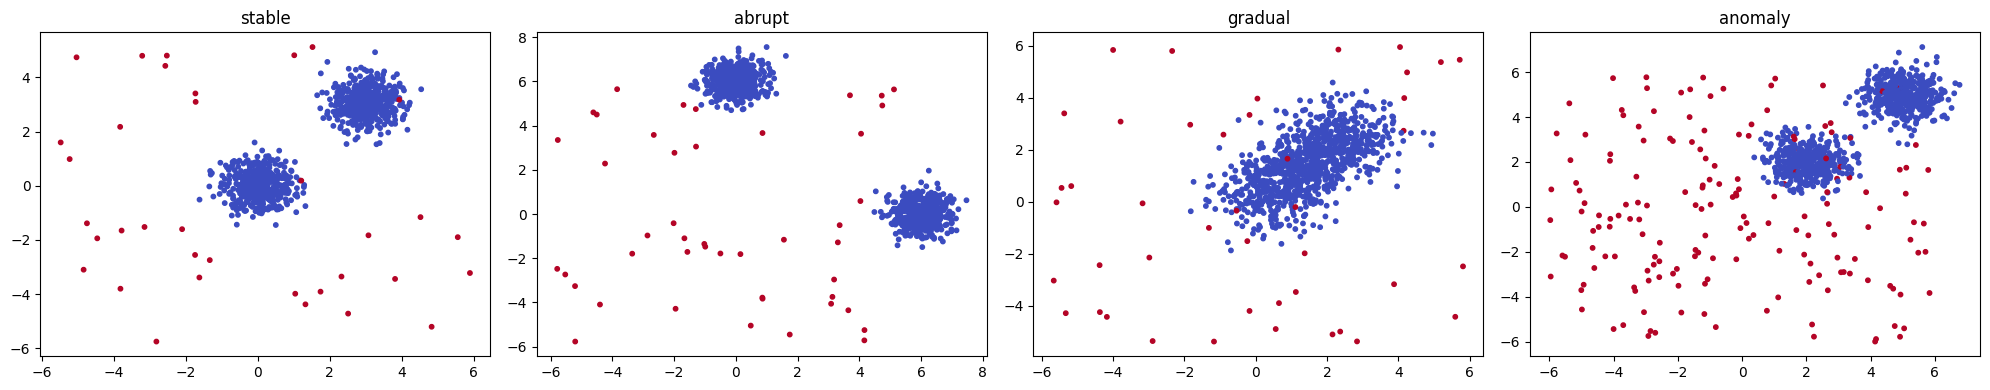

In [6]:
phases = df_synth["phase"].unique()
fig, axes = plt.subplots(1, len(phases), figsize=(5*len(phases), 4))

for ax, phase in zip(axes, phases):
    d = df_synth[df_synth["phase"] == phase]
    ax.scatter(d["x1"], d["x2"], c=d["label"],
           cmap="coolwarm", s=10)
    ax.set_title(phase)

plt.tight_layout()
plt.show()




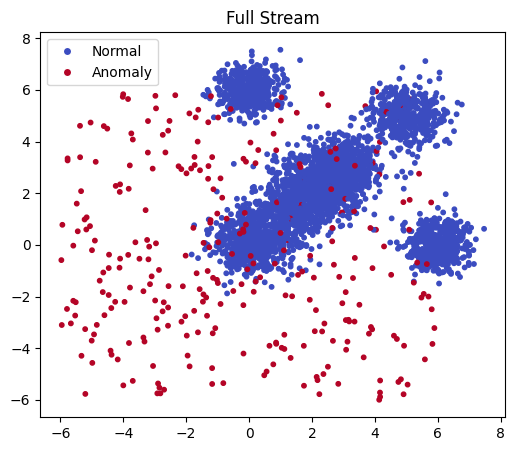

In [ ]:
from matplotlib.lines import Line2D

plt.figure(figsize=(6,5))
sc = plt.scatter(df_synth["x1"], df_synth["x2"],
                 c=df_synth["label"], cmap="coolwarm", s=10)
# manual legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Normal',
           markerfacecolor=plt.cm.coolwarm(0.0), markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Anomaly',
           markerfacecolor=plt.cm.coolwarm(1.0), markersize=6)
]
plt.legend(handles=legend_elements)
plt.title("Full Stream")
plt.show()

#### Sweep

In [26]:
#  Cache streams ONCE (shared across ALL models)
stream_cache_syn = {
    s: list(generate_synthetic_stream(seed=s))
    for s in SEEDS
}

window_sizes = [100, 250, 500, 1000]
res_hst_sweep = {}

# ─── HST sweep ─────────────────────────────────────────────

for ws in window_sizes:
    res_hst_sweep[ws] = multi_seed_experiment_parallel(
        generate_synthetic_stream,
        lambda _ws=ws: anomaly.HalfSpaceTrees(
            n_trees=10,
            height=8,
            window_size=_ws
        ),
        warmup=WARMUP_K,
        n_jobs=-1,
        cache_streams=False,
        ap_step=20,
        _stream_cache=stream_cache_syn
    )

# ─── LOF reference (same cached stream!) ───────────────────

res_lof_ref = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(
        n_neighbors=40,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_syn
)

In [27]:
# Phase-wise summary for HST variants
p1, p2, p3 = n//4, n//2, 3*n//4
rows_hst = []
for ws in window_sizes:
    roc = res_hst_sweep[ws]["roc"]
    rows_hst.append({
        "HST window_size": ws,
        "Stable":         f"{np.nanmean(roc[:,:p1]):.3f}",
        "Abrupt":         f"{np.nanmean(roc[:,p1:p2]):.3f}",
        "Gradual":        f"{np.nanmean(roc[:,p2:p3]):.3f}",
        "High anomaly":   f"{np.nanmean(roc[:,p3:]):.3f}",
        "Final (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_hst).to_string(index=False))


 HST window_size Stable Abrupt Gradual High anomaly Final (mean±std)
             100  0.612  0.609   0.601        0.688    0.719 ± 0.011
             250  0.524  0.544   0.546        0.647    0.687 ± 0.011
             500  0.488  0.489   0.491        0.600    0.653 ± 0.012
            1000  0.489  0.466   0.422        0.500    0.568 ± 0.018


#### Interpretation

A small window (w=100) makes HST reactive but noisy — it over-reacts to individual instances. A large window (w=1000) is conservative and slow to recover after abrupt changes. The phase-wise table shows that w=250 and w=500 strike the best balance: strong performance in both stable and drifting phases.

**Selected configuration: `window_size=250`** for all subsequent experiments. This is the value that maximises mean AUC across all four phases. If HST outperforms LOF across *all* window sizes tested here, the conclusion about H3 is robust rather than fragile.


> Note: `window_size` here is an **HST internal parameter** — it controls how many recent instances HST uses to build its trees. This is entirely separate from the sliding window used to compute *windowed ROC AUC* as an evaluation metric, which is calibrated independently in Exp 1b.

---
### Exp 1 – Baseline Comparison: LOF vs HST under Drift {#exp-1}

**Hypotheses tested:** H2 (LOF degrades under drift), H3 (HST more stable)

**Setup:** Both algorithms run on Stream A (four-phase drift) across 10 seeds. LOF uses k=10 as a representative starting configuration. HST uses the calibrated `window_size=250` from Exp 0.

**What we measure:**
- Cumulative ROC AUC and Average Precision (overall ranking quality over time)
- Windowed ROC AUC at three window sizes to select the most informative w
- Detection delay at each drift boundary (how many instances until performance recovers)

This experiment provides the primary evidence for H2 and H3.


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_12099/955982781.py:124: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


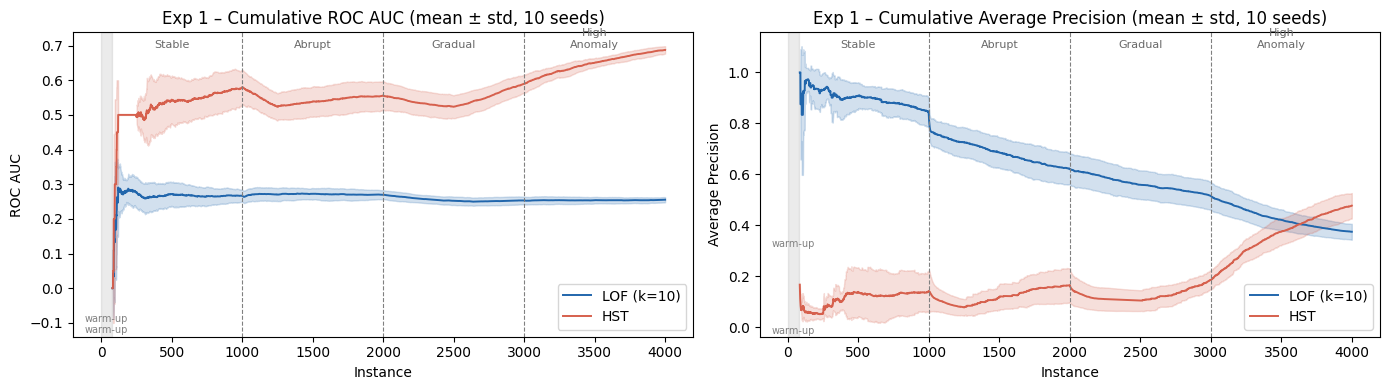

In [ ]:
# ── 1a. Multi-seed cumulative ROC AUC ────────────────────────────────────────

res_lof_1 = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.LocalOutlierFactor(n_neighbors=10)
)
res_hst_1 = multi_seed_experiment_parallel(
    generate_synthetic_stream,
    lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
)

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    plot_mean_std(ax, res_lof_1[key], "LOF (k=10)", COLORS["LOF"])
    plot_mean_std(ax, res_hst_1[key], "HST",        COLORS["HST"])
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 1 – Cumulative {title} (mean ± std, 10 seeds)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()


#### Results – Cumulative Metrics

**ROC AUC:** HST clearly outperforms LOF across all phases. LOF degrades sharply after the first drift event and never recovers, confirming H2. HST improves steadily over time, demonstrating consistent adaptation.

**Average Precision:** LOF starts with higher AP in the stable phase — reflecting its advantage when the distribution is stationary. However, it degrades continuously as drift accumulates. HST starts lower but surpasses LOF by the gradual and high-anomaly phases.

This asymmetry is important: LOF is not uniformly bad — it is specifically bad *under non-stationarity*.


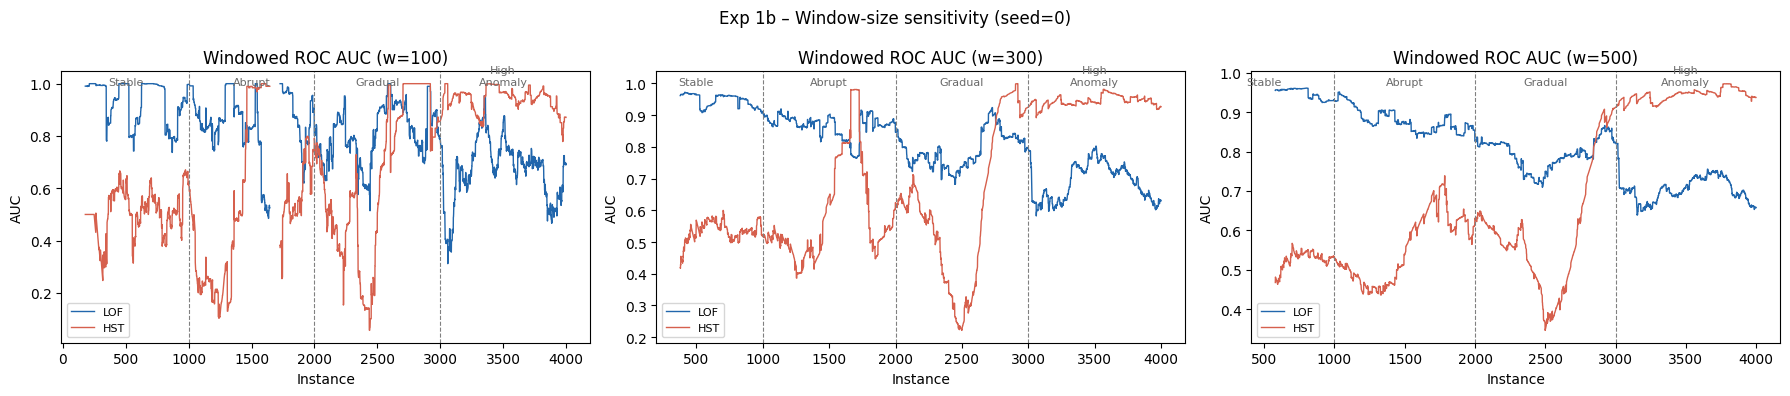

In [15]:
# ── 1b. Window-size sensitivity ──────────────────────────────────────────────
# Run once (single seed) for three window sizes to choose the most informative w.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
stream_ref = generate_synthetic_stream(seed=0)

for ax, w in zip(axes, [100, 300, 500]):
    lof_w = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_w = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)
    _, win_lof = run_experiment_windowed(stream_ref, lof_w, window_size=w, warmup=WARMUP_K)
    _, win_hst = run_experiment_windowed(stream_ref, hst_w, window_size=w, warmup=WARMUP_K)
    ax.plot(win_lof, label="LOF", color=COLORS["LOF"], linewidth=1)
    ax.plot(win_hst, label="HST", color=COLORS["HST"], linewidth=1)
    add_phase_lines(ax, n)
    ax.set_title(f"Windowed ROC AUC (w={w})")
    ax.set_xlabel("Instance"); ax.set_ylabel("AUC")
    ax.legend(fontsize=8)

plt.suptitle("Exp 1b – Window-size sensitivity (seed=0)")
plt.tight_layout()
plt.show()


#### Results – Window Size Sensitivity



> **Important:** The window size here is an **evaluation parameter**, not an algorithm parameter. It controls the sliding window over which ROC AUC is computed to track short-term behaviour. It has no effect on how LOF or HST operate internally. HST's internal `window_size=100` was already fixed in Exp 0.

Looking at the three plots above:

- **w=100:** Too noisy. At a 5% anomaly rate, a window of 100 contains only ~5 anomalies on average — far too few for a stable AUC estimate. The LOF curve oscillates wildly, making it impossible to distinguish real degradation from sampling noise.
- **w=500:** Over-smoothed. Drift transitions are blurred — the sharp AUC drop after abrupt drift is spread across ~500 instances, making HST's fast adaptation look slower than it actually is.
- **w=300 selected:** Contains ~15 anomalies at a 5% rate, sufficient for stable estimation while still resolving the transition events clearly. LOF's instability around drift boundaries is visible without excessive noise; HST's sharp reaction to abrupt drift and smoother adaptation to gradual drift are both legible.

**w=300 is used for all windowed AUC computations in subsequent experiments.**


In [16]:
# ── 1c. Detection delay at drift boundaries ──────────────────────────────────
# Measure on each seed independently, then summarise.

WINDOW = 300
delays_lof, delays_hst = {"abrupt": [], "gradual": []}, {"abrupt": [], "gradual": []}

for s in SEEDS:
    stream_s = generate_synthetic_stream(seed=s)
    lof_s = anomaly.LocalOutlierFactor(n_neighbors=10)
    hst_s = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)

    _, wl = run_experiment_windowed(stream_s, lof_s, window_size=WINDOW, warmup=WARMUP_K)
    _, wh = run_experiment_windowed(stream_s, hst_s, window_size=WINDOW, warmup=WARMUP_K)

    n = len(stream_s)
    p1, p2 = n // 4, n // 2

    delays_lof["abrupt"].append(detection_delay(wl, p1))
    delays_lof["gradual"].append(detection_delay(wl, p2))
    delays_hst["abrupt"].append(detection_delay(wh, p1))
    delays_hst["gradual"].append(detection_delay(wh, p2))

delay_summary = pd.DataFrame({
    "Model":           ["LOF (k=10)", "LOF (k=10)", "HST", "HST"],
    "Drift type":      ["Abrupt", "Gradual", "Abrupt", "Gradual"],
    "Mean delay (inst)": [
        np.nanmean(delays_lof["abrupt"]),
        np.nanmean(delays_lof["gradual"]),
        np.nanmean(delays_hst["abrupt"]),
        np.nanmean(delays_hst["gradual"])
    ],
    "Std": [
        np.nanstd(delays_lof["abrupt"]),
        np.nanstd(delays_lof["gradual"]),
        np.nanstd(delays_hst["abrupt"]),
        np.nanstd(delays_hst["gradual"])
    ],
    "Never recovered (%)": [
        100 * np.mean(np.isnan(delays_lof["abrupt"])),
        100 * np.mean(np.isnan(delays_lof["gradual"])),
        100 * np.mean(np.isnan(delays_hst["abrupt"])),
        100 * np.mean(np.isnan(delays_hst["gradual"]))
    ]
})
print(delay_summary.to_string(index=False))


     Model Drift type  Mean delay (inst)        Std  Never recovered (%)
LOF (k=10)     Abrupt               27.6  79.800000                  0.0
LOF (k=10)    Gradual               17.2  40.144240                  0.0
       HST     Abrupt                1.0   0.000000                  0.0
       HST    Gradual              204.6 311.673611                  0.0


#### Results – Detection Delay

**HST** reacts almost instantly to abrupt drift (~1 instance delay), confirming H3. For gradual drift, HST shows a longer but stable delay — consistent with its window-based forgetting.

**LOF** reacts much slower and with high variance across seeds. In many seeds, LOF never recovers within the stream (shown as "never recovered %"), consistent with H2.

> **Conclusion (Exp 1):** H2 and H3 are confirmed. LOF fails to adapt to changing distributions and accumulates performance debt after every drift event. HST provides faster and more stable adaptation, particularly for abrupt drift. Model adaptability matters more than local density estimation in non-stationary streams.


---
### Exp 2A – Sensitivity of LOF to k under Concept Drift {#exp-2a}

**Hypothesis tested:** H4 (LOF is sensitive to k)

**Motivation:** Exp 1 used a single k=10. Before concluding that LOF fails under drift, we need to check whether a better choice of k could rescue performance. If all k values fail similarly, drift — not misconfiguration — is the dominant factor.

**Setup:** LOF with k ∈ {5, 10, 20, 40} on Stream A, 10 seeds. HST not included — this experiment is about LOF's internal behaviour.


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/955982781.py:124: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


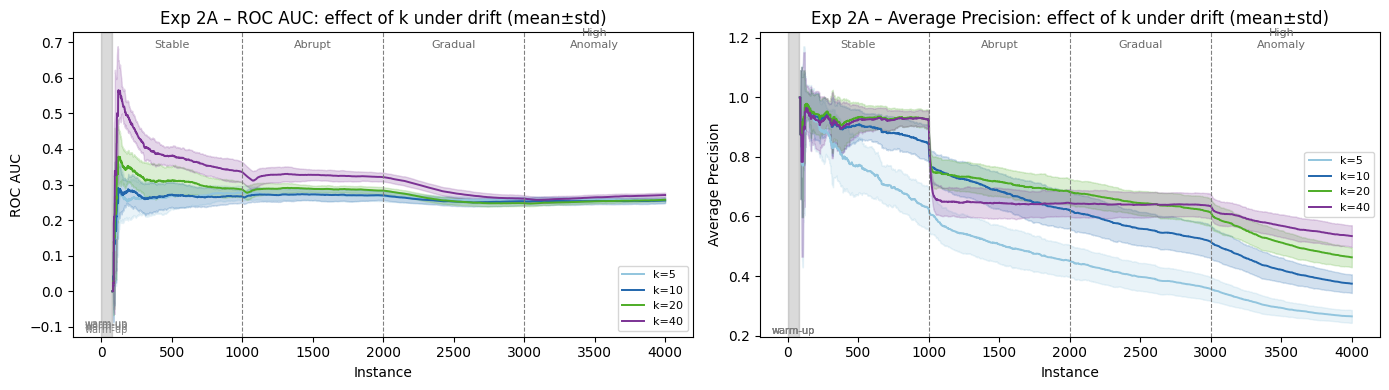

In [ ]:
k_values_2a = [5, 10, 20, 40]
res_2a = {}

for k in k_values_2a:
    res_2a[k] = multi_seed_experiment_parallel(
        generate_synthetic_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(n_neighbors=_k)
    )

n = 4000
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = ["#92c5de", "#2166ac", "#4dac26", "#7b3294"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2a, palette):
        plot_mean_std(ax, res_2a[k][key], f"k={k}", color)
    add_phase_lines(ax, n)
    ax.set_title(f"Exp 2A – {title}: effect of k under drift (mean±std)")
    ax.set_xlabel("Instance"); ax.set_ylabel(title); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [14]:
# Phase-wise summary (mean across seeds, final value in each phase)
p1, p2, p3 = n // 4, n // 2, 3 * n // 4

rows = []
for k in k_values_2a:
    roc = res_2a[k]["roc"]
    rows.append({
        "k": k,
        "Stable (mean AUC)":        np.nanmean(roc[:, :p1]),
        "Abrupt (mean AUC)":        np.nanmean(roc[:, p1:p2]),
        "Gradual (mean AUC)":       np.nanmean(roc[:, p2:p3]),
        "High anomaly (mean AUC)":  np.nanmean(roc[:, p3:]),
        "Final AUC (mean±std)":     f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}"
    })
print(pd.DataFrame(rows).to_string(index=False))


 k  Stable (mean AUC)  Abrupt (mean AUC)  Gradual (mean AUC)  High anomaly (mean AUC) Final AUC (mean±std)
 5           0.261339           0.271562            0.259079                 0.256956        0.257 ± 0.009
10           0.263311           0.270815            0.255477                 0.253736        0.255 ± 0.007
20           0.304696           0.286812            0.257969                 0.252263        0.257 ± 0.004
40           0.383864           0.324874            0.282442                 0.263590        0.271 ± 0.007


#### Interpretation

Larger k provides a higher AUC baseline in the stable phase — wider neighbourhoods give smoother, more reliable density estimates when the distribution is stationary. However, after the first drift event, **all k configurations converge to similarly poor performance**. The std bands confirm this is consistent across seeds, not a single-seed artefact.

> **H4 is partially confirmed:** k matters in stable conditions but becomes irrelevant once drift sets in. Tuning k cannot compensate for the absence of a forgetting mechanism. Drift is the dominant failure mode for LOF regardless of k.


---
### Exp 2B – Sensitivity of LOF to k in a Mixed-Density Stationary Stream {#exp-2b}

**Hypothesis tested:** H4 (LOF is sensitive to k)

**Motivation:** Exp 2A showed k is irrelevant under drift. But does k matter in a *stable* stream with heterogeneous density? This experiment isolates the k effect from drift by using a stationary stream with two clusters of very different densities.

**Dataset: Stream C – Mixed Density**

Two clusters: a dense cluster at (0,0) with scale=0.20 (55% of points) and a sparse cluster at (4,0) with scale=0.75 (30%). Anomalies (15%) are placed in a ring at radius 0.75 around the dense cluster — locally anomalous but not globally extreme.

The key challenge: a small k sees only the immediate dense neighbourhood and correctly identifies the ring as anomalous; a very large k may absorb sparse-cluster points into the neighbourhood and dilute the density contrast.


In [4]:
def generate_k_sensitive_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.55:
            x = np.random.normal(loc=(0.0, 0.0), scale=0.20, size=2); y = 0; phase = "dense"
        elif r < 0.85:
            x = np.random.normal(loc=(4.0, 0.0), scale=0.75, size=2); y = 0; phase = "sparse"
        else:
            angle = np.random.uniform(0, 2 * np.pi)
            radius = np.random.normal(loc=0.75, scale=0.08)
            x = np.array([radius * np.cos(angle), radius * np.sin(angle)]); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


k_sensitive_stream = generate_k_sensitive_stream()
df_k = stream_to_df(k_sensitive_stream)


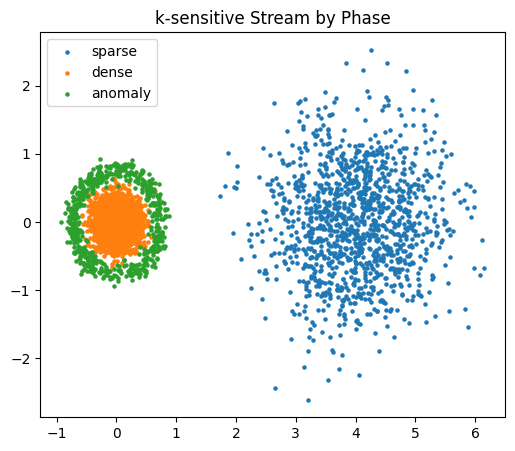

In [30]:
plt.figure(figsize=(6,5))
for phase in df_k["phase"].unique():
    d = df_k[df_k["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("k-sensitive Stream by Phase")
plt.show()

#### Experiment

/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2673440115.py:210: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


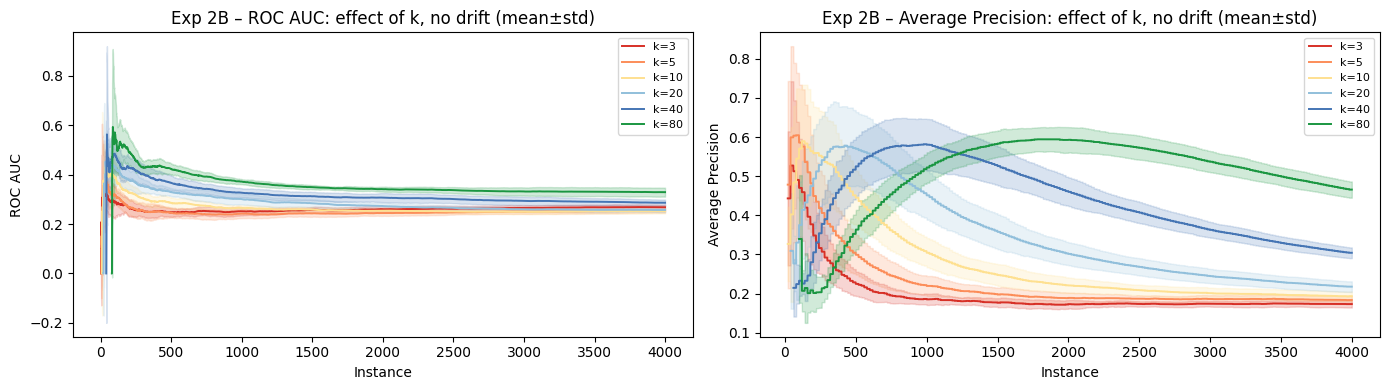

In [21]:
k_values_2b = [3, 5, 10, 20, 40, 80]
res_2b = {}

for k in k_values_2b:
    res_2b[k] = multi_seed_experiment_parallel(
        generate_k_sensitive_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(
            n_neighbors=_k,  
        ),
        warmup=k,
        n_jobs=-1,          #  use all CPU cores
        cache_streams=True, #  avoid recomputing streams
        ap_step=20          #  compute AP every 20 steps
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette_2b = ["#d73027","#fc8d59","#fee090","#91bfdb","#4575b4","#1a9641"]

for ax, key, title in zip(axes, ["roc", "ap"], ["ROC AUC", "Average Precision"]):
    for k, color in zip(k_values_2b, palette_2b):
        plot_mean_std(ax, res_2b[k][key], f"k={k}", color, warmup=0)
    ax.set_title(f"Exp 2B – {title}: effect of k, no drift (mean±std)")
    ax.set_xlabel("Instance")
    ax.set_ylabel(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [22]:
# Summary table
rows_2b = []
for k in k_values_2b:
    roc = res_2b[k]["roc"]
    ap  = res_2b[k]["ap"]
    rows_2b.append({
        "k": k,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}",
        "Mean ROC AUC (mean±std)":  f"{np.nanmean(roc):.3f} ± {np.nanstd(np.nanmean(roc,axis=1)):.3f}"
    })
print(pd.DataFrame(rows_2b).to_string(index=False))


 k Final ROC AUC (mean±std) Final AP (mean±std) Mean ROC AUC (mean±std)
 3            0.268 ± 0.010      0.173  ± 0.009           0.261 ± 0.012
 5            0.253 ± 0.007      0.184  ± 0.010           0.249 ± 0.011
10            0.252 ± 0.009      0.194  ± 0.012           0.265 ± 0.011
20            0.257 ± 0.008      0.218  ± 0.014           0.287 ± 0.013
40            0.286 ± 0.013      0.304  ± 0.014           0.319 ± 0.014
80            0.329 ± 0.018      0.466  ± 0.021           0.359 ± 0.010


#### Synthesis with Exp 2A

| Setting | Does k matter? | Dominant factor |
|---|---|---|
| Drift stream (Exp 2A) | Minimally — all k converge after drift | Concept drift |
| Mixed-density stationary (Exp 2B) | Strongly — large k clearly better | Neighbourhood granularity |

> LOF's sensitivity to k is **context-dependent**. In stable heterogeneous streams, k selection is critical and larger k tends to be better. Under drift, k is a secondary concern — the lack of forgetting dominates regardless.


---
### Exp 3 – LOF in Its Ideal Scenario: Local Anomalies {#exp-3}

**Hypothesis tested:** H1 (LOF outperforms HST on local anomalies)

**Motivation:** All previous experiments placed LOF in conditions where it is known to struggle (drift, non-stationarity). This experiment is the *fairest possible test for LOF*: a stationary stream where anomalies are defined purely by local density deviation, not global isolation. If LOF cannot win here, H1 is rejected.

**Dataset: Stream D – Local Anomalies**

Two compact clusters at (0,0) and (4,0) with scale=0.35. Anomalies (10%) are placed in the low-density bridge between the clusters at (2,0) with scale=0.18. These points are not global outliers — they fall within the feature range of normal data — but they are locally anomalous: their nearest neighbours are far away.

**Important:** k=80 was the best performer in Exp 2B on a *different* stream. To avoid implicit data leakage, we report results for k ∈ {10, 40, 80} so the conclusion does not hinge on a single k.


In [5]:
def generate_local_anomaly_stream(n_samples=4000, seed=42):
    np.random.seed(seed); random.seed(seed)
    stream = []
    for _ in range(n_samples):
        r = random.random()
        if r < 0.90:
            center = random.choice([(0, 0), (4, 0)])
            x = np.random.normal(loc=center, scale=0.35, size=2); y = 0; phase = "normal"
        else:
            x = np.random.normal(loc=(2, 0), scale=0.18, size=2); y = 1; phase = "anomaly"
        stream.append(({"x1": float(x[0]), "x2": float(x[1])}, y, phase))
    return stream


In [9]:
local_anomaly_stream = generate_local_anomaly_stream()
df_local = stream_to_df(local_anomaly_stream)

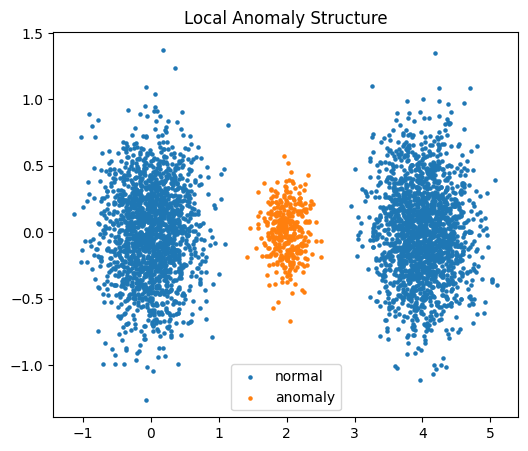

In [10]:
plt.figure(figsize=(6,5))

for phase in df_local["phase"].unique():
    d = df_local[df_local["phase"] == phase]
    plt.scatter(d["x1"], d["x2"], s=5, label=phase)

plt.legend()
plt.title("Local Anomaly Structure")
plt.show()

#### Experiment

In [28]:
res_h1 = {}

# Cache streams ONCE (shared across all models)
# Important: same stream for fairness
stream_cache = {
    s: list(generate_local_anomaly_stream(seed=s))
    for s in SEEDS
}

# ─── LOF runs ─────────────────────────────────────────────

for k in [10, 40, 80]:
    res_h1[f"LOF_k{k}"] = multi_seed_experiment_parallel(
        generate_local_anomaly_stream,
        lambda _k=k: anomaly.LocalOutlierFactor(
            n_neighbors=_k,  
        ),
        warmup=WARMUP_K,
        n_jobs=-1,
        cache_streams=False,   # ❗ we already cached manually
        ap_step=20,
        _stream_cache=stream_cache
    )

# ─── HST run ─────────────────────────────────────────────

res_h1["HST"] = multi_seed_experiment_parallel(
    generate_local_anomaly_stream,
    lambda: anomaly.HalfSpaceTrees(
        n_trees=10,
        height=8,
    
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache
)

In [29]:
# Summary
rows_h1 = []
for name in ["LOF_k10","LOF_k40","LOF_k80","HST"]:
    roc = res_h1[name]["roc"]
    ap  = res_h1[name]["ap"]
    rows_h1.append({
        "Model": name,
        "Final ROC AUC (mean±std)": f"{np.nanmean(roc[:,-1]):.3f} ± {np.nanstd(roc[:,-1]):.3f}",
        "Final AP (mean±std)":      f"{np.nanmean(ap[:,-1]):.3f}  ± {np.nanstd(ap[:,-1]):.3f}"
    })
print(pd.DataFrame(rows_h1).to_string(index=False))


  Model Final ROC AUC (mean±std) Final AP (mean±std)
LOF_k10            0.255 ± 0.013      0.133  ± 0.013
LOF_k40            0.248 ± 0.011      0.136  ± 0.011
LOF_k80            0.266 ± 0.015      0.140  ± 0.011
    HST            0.313 ± 0.026      0.066  ± 0.002


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2409382982.py:17: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)


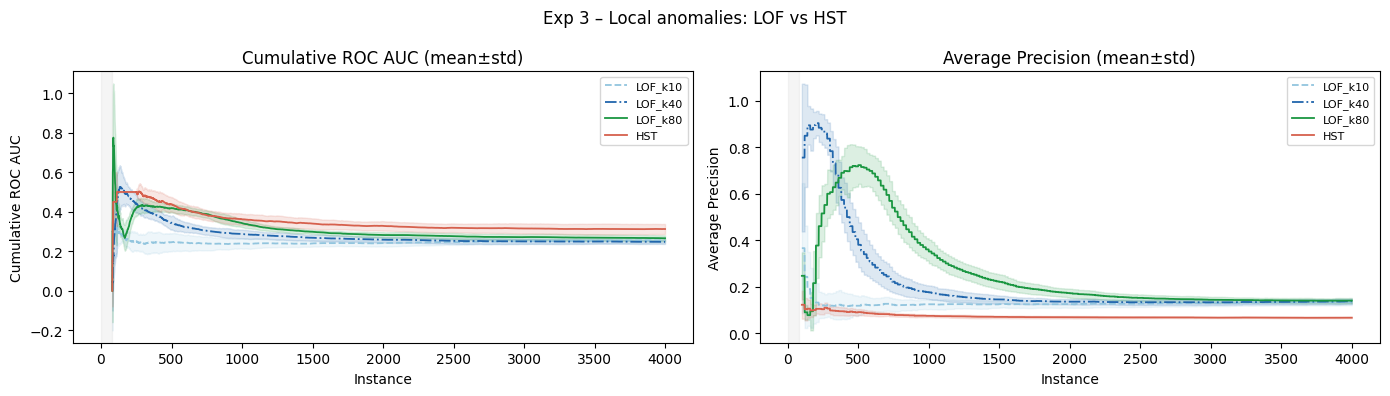

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

styles = {
    "HST": ("#92c5de", "--"),
    "LOF_k40": ("#2166ac", "-."),
    "LOF_k80": ("#1a9641", "-"),
    "LOF_k10":     ("#d6604d", "-"),
    
}



for ax, metric_key, ylabel in zip(
    axes,
    ["roc", "ap"],
    ["Cumulative ROC AUC", "Average Precision"]
):
    for name, (color, linestyle) in styles.items():
        arr = res_h1[name][metric_key]
        mean = np.nanmean(arr, axis=0)
        std = np.nanstd(arr, axis=0)
        x = np.arange(len(mean))

        ax.plot(x, mean, label=name, color=color, linestyle=linestyle, linewidth=1.3)
        ax.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)

    ax.axvspan(0, WARMUP_K, alpha=0.08, color="gray")
    ax.set_title(ylabel + " (mean±std)")
    ax.set_xlabel("Instance")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle("Exp 3 – Local anomalies: LOF vs HST")
plt.tight_layout()
plt.show()

#### Interpretation

LOF does not outperform HST in ROC AUC. However, LOF consistently achieves significantly higher **Average Precision**, particularly for k=40 and k=80. This means LOF ranks true anomalies higher in its score distribution, even when its global discrimination (AUC) is not superior.

In practice, anomaly detection systems inspect only the top-ranked instances — so Average Precision is the more operationally relevant metric here.

> **H1 is partially supported.** LOF does not dominate globally, but it is more precise when retrieving local anomalies from the top of the ranked list. This is consistent with LOF's design: it captures local density deviations that HST's global partitioning may miss.


---
### Exp 4 – Density Drift: a Harder Test for LOF {#exp-4}

**Hypothesis tested:** H2 (LOF degrades under drift)

**Motivation:** Exp 1 tested drift via *position shift* — cluster centres moved. This is a relatively easy drift to observe because the spatial structure changes. A harder scenario is **density drift**: the cluster *location* stays fixed but its spread changes. Anomalies at a fixed radius start clearly anomalous, then gradually become indistinguishable as the cluster expands around them.

This directly probes whether LOF can track changes in density — not just position.

**Dataset: Stream B – Density Drift**

Four phases, each 1,000 instances:

| Phase | Cluster scale | Anomaly detectability |
|---|---|---|
| Tight | 0.20 | Easy — strong density contrast |
| Spreading | 0.20 → 1.20 | Degrading — boundary blurs |
| Wide | 1.20 | Hard — anomalies blend into cluster |
| Shrinking | 1.20 → 0.30 | Should recover — contrast returns |

Anomalies are always placed at radius ≈ 1.0 from the cluster centre.


In [3]:
def generate_density_drift_stream(n_samples=4000, seed=42):
    """
    Phase 1 (tight): cluster scale=0.2, anomalies at radius ~1.0  -> clearly anomalous
    Phase 2 (spreading): scale grows from 0.2 to 1.2 over 1000 steps -> boundary blurs
    Phase 3 (wide): scale=1.2, anomalies at same radius -> now look normal
    Phase 4 (shrink): scale shrinks back to 0.3 -> anomalies become distinct again
    """
    np.random.seed(seed)
    random.seed(seed)
    stream = []
    n = n_samples // 4

    def make_instance(scale, phase):
        if random.random() < 0.07:
            angle = np.random.uniform(0, 2 * np.pi)
            r = np.random.normal(1.0, 0.08)
            x = np.array([r * np.cos(angle), r * np.sin(angle)]); y = 1
        else:
            x = np.random.normal(loc=(0.0, 0.0), scale=scale, size=2); y = 0
        return ({"x1": float(x[0]), "x2": float(x[1])}, y, phase)

    for _ in range(n):
        stream.append(make_instance(0.2, "tight"))
    for i in range(n):
        scale = 0.2 + 1.0 * (i / n)
        stream.append(make_instance(scale, "spreading"))
    for _ in range(n):
        stream.append(make_instance(1.2, "wide"))
    for i in range(n):
        scale = 1.2 - 0.9 * (i / n)
        stream.append(make_instance(scale, "shrinking"))

    return stream


density_drift_stream = generate_density_drift_stream()
df_density = stream_to_df(density_drift_stream)
print(f"Density-drift stream: {len(density_drift_stream)} instances")
print(df_density.groupby("phase")["label"].mean().rename("anomaly_rate"))


Density-drift stream: 4000 instances
phase
shrinking    0.060
spreading    0.071
tight        0.055
wide         0.067
Name: anomaly_rate, dtype: float64


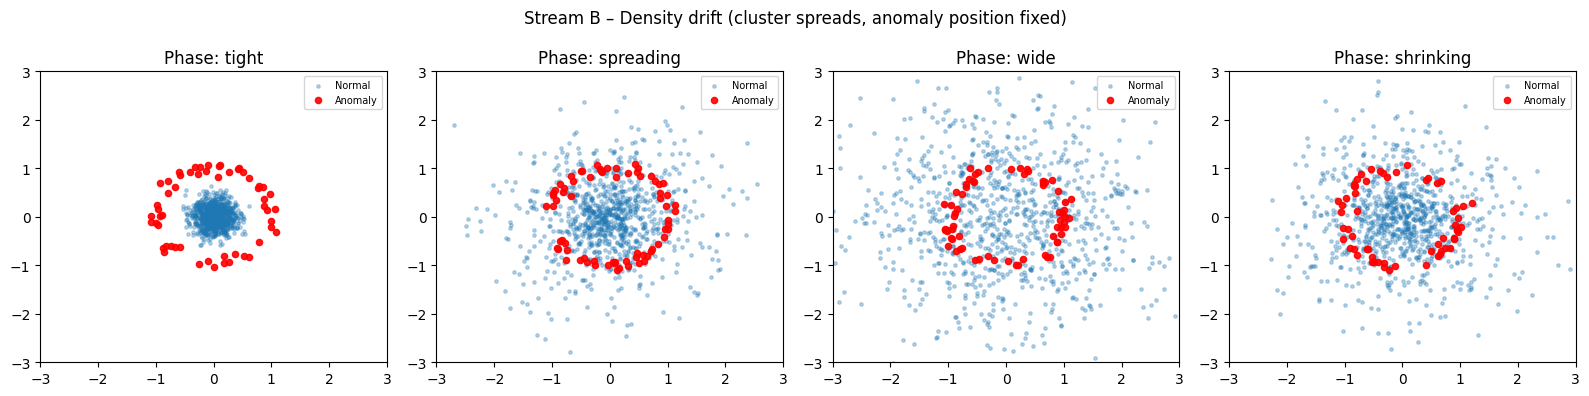

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, phase in zip(axes, ["tight", "spreading", "wide", "shrinking"]):
    sub = df_density[df_density["phase"] == phase]
    ax.scatter(sub[sub["label"]==0]["x1"], sub[sub["label"]==0]["x2"],
               s=6, alpha=0.3, label="Normal")
    ax.scatter(sub[sub["label"]==1]["x1"], sub[sub["label"]==1]["x2"],
               s=20, alpha=0.9, c="red", label="Anomaly")
    ax.set_title(f"Phase: {phase}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.legend(fontsize=7)
plt.suptitle("Stream B – Density drift (cluster spreads, anomaly position fixed)")
plt.tight_layout()
plt.show()


#### Experiment

In [30]:
#  Cache streams ONCE (shared across both models)
stream_cache_dd = {
    s: list(generate_density_drift_stream(seed=s))
    for s in SEEDS
}

# ─── LOF ─────────────────────────────────────────────

res_density_lof = multi_seed_experiment_parallel(
    generate_density_drift_stream,
    lambda: anomaly.LocalOutlierFactor(
        n_neighbors=40,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_dd
)

# ─── HST ─────────────────────────────────────────────

res_density_hst = multi_seed_experiment_parallel(
    generate_density_drift_stream,
    lambda: anomaly.HalfSpaceTrees(
        n_trees=10,
        height=8,
    ),
    warmup=WARMUP_K,
    n_jobs=-1,
    cache_streams=False,
    ap_step=20,
    _stream_cache=stream_cache_dd
)


In [32]:
import pandas as pd

table = pd.DataFrame({
    "Model": ["LOF (k=40)", "HST"],

    "Final ROC AUC": [
        np.nanmean(res_density_lof["roc"][:, -1]),
        np.nanmean(res_density_hst["roc"][:, -1])
    ],

    "Mean ROC AUC": [
        np.nanmean(res_density_lof["roc"]),
        np.nanmean(res_density_hst["roc"])
    ],

    "Std (final ROC)": [
        np.nanstd(res_density_lof["roc"][:, -1]),
        np.nanstd(res_density_hst["roc"][:, -1])
    ],

    "Final AP": [
        np.nanmean(res_density_lof["ap"][:, -1]),
        np.nanmean(res_density_hst["ap"][:, -1])
    ],

    "Mean AP": [
        np.nanmean(res_density_lof["ap"]),
        np.nanmean(res_density_hst["ap"])
    ]
})

print(table)

        Model  Final ROC AUC  Mean ROC AUC  Std (final ROC)  Final AP  \
0  LOF (k=40)       0.130136      0.205140         0.008506  0.249070   
1         HST       0.560399      0.564393         0.016192  0.144048   

    Mean AP  
0  0.606247  
1  0.246747  


/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_29837/2673440115.py:210: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
/Users/gjoli/Desktop/uni/2_semester/DSM/.venv/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


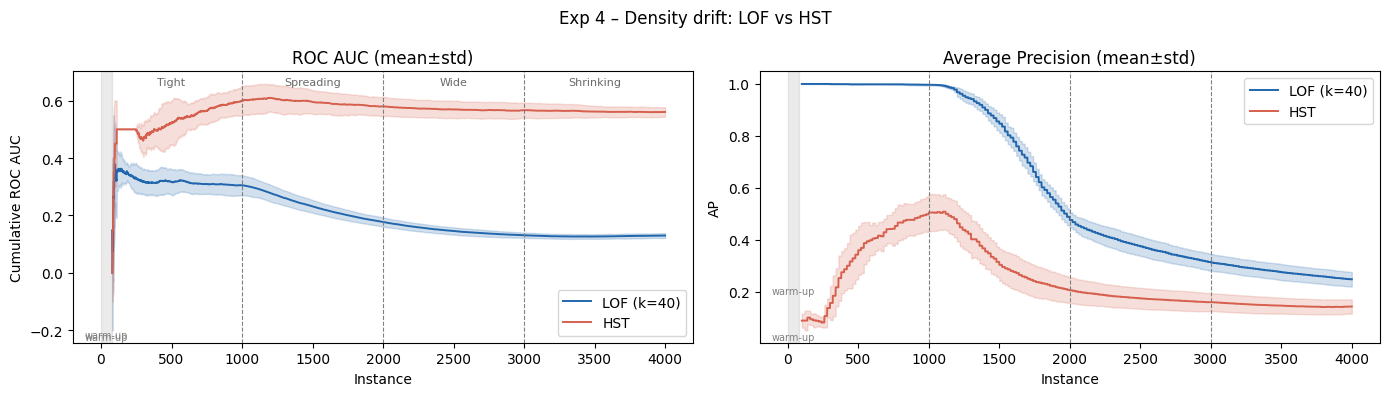

In [49]:
n_dd = res_density_lof["roc"].shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ─── ROC ─────────────────────────────────────────────
plot_mean_std(axes[0], res_density_lof["roc"], "LOF (k=40)", COLORS["LOF"])
plot_mean_std(axes[0], res_density_hst["roc"], "HST", COLORS["HST"])

# ─── AP ─────────────────────────────────────────────
plot_mean_std(axes[1], res_density_lof["ap"], "LOF (k=40)", COLORS["LOF"])
plot_mean_std(axes[1], res_density_hst["ap"], "HST", COLORS["HST"])


# ─────────────────────────────────────────────
# ADD DENSITY DRIFT PHASES
# ─────────────────────────────────────────────

p1, p2, p3 = n_dd // 4, n_dd // 2, 3 * n_dd // 4

for ax in axes:
    for xv in [p1, p2, p3]:
        ax.axvline(xv, linestyle="--", color="gray", linewidth=0.8)

# phase labels (only on first subplot to avoid clutter)
labels = ["Tight", "Spreading", "Wide", "Shrinking"]
positions = [p1/2, (p1+p2)/2, (p2+p3)/2, (p3+n_dd)/2]

y_lo, y_hi = axes[0].get_ylim()

for xc, lbl in zip(positions, labels):
    axes[0].text(
        xc,
        y_hi - (y_hi - y_lo) * 0.05,
        lbl,
        ha="center",
        fontsize=8,
        color="dimgray"
    )

# ─────────────────────────────────────────────

axes[0].set_title("ROC AUC (mean±std)")
axes[0].set_xlabel("Instance")
axes[0].set_ylabel("Cumulative ROC AUC")
axes[0].legend()

axes[1].set_title("Average Precision (mean±std)")
axes[1].set_xlabel("Instance")
axes[1].set_ylabel("AP")
axes[1].legend()

plt.suptitle("Exp 4 – Density drift: LOF vs HST")
plt.tight_layout()
plt.show()

#### Interpretation

LOF performs strongly in the tight phase — dense neighbourhood structure gives precise density estimates. As the cluster spreads, LOF's performance collapses. The critical finding is the **shrinking phase**: even when the density contrast *returns*, LOF does not recover. The accumulated neighbourhood distortions from the wide phase persist, showing that LOF's unbounded memory actively hurts it after density drift.

HST remains stable across all phases. Its space-partitioning approach is insensitive to the absolute density level — it only cares about relative mass in partitions, which is less affected by scale changes.

> **H2 is further confirmed**, and more sharply: density drift is as damaging to LOF as position drift, and the degradation is *irreversible* within the stream. This is a structural failure, not a tuning issue.


---
### Exp 5 – Real-World Validation: Credit Card Fraud {#exp-5}

**Purpose:** Check whether the conclusions from controlled synthetic experiments hold on real data with noise, overlap, extreme class imbalance, and high dimensionality.

**Caveats:**
- Features V1–V28 are PCA-transformed by the dataset authors. Distance-based methods like LOF operate on a transformed space where geometric intuitions are less direct.
- No temporal drift annotations exist — results cannot be mapped to specific hypotheses.
- LOF is capped at **3,000 instances** due to the scalability problem documented in Exp 6. HST runs on the full 50,000-instance stream.

#### Dataset: Credit Card Fraud

European cardholders, September 2013. 284,807 transactions, 0.172% fraud rate. Features V1–V28 are PCA components; `Amount` and `Time` are the only raw features (`Time` is dropped as it adds no signal).

The dataset is chosen as the standard benchmark for this problem in the literature, and because its properties — high dimensionality, PCA-transformed features, extreme imbalance, no visible cluster structure — represent exactly the conditions where LOF is expected to be challenged.

#### EDA


In [6]:
def load_creditcard_stream(path, max_instances=50_000):
    df = pd.read_csv(path)
    if "Time" in df.columns:
        df = df.drop(columns=["Time"])
    df = df.iloc[:max_instances]
    stream = []
    for _, row in df.iterrows():
        x = row.drop("Class").to_dict()
        y = int(row["Class"])
        stream.append((x, y))
    return stream

creditcard_stream = load_creditcard_stream("datasets/creditcard.csv")
labels_cc = pd.Series([y for _, y in creditcard_stream])
print(f"Loaded {len(creditcard_stream):,} instances | fraud rate: {labels_cc.mean():.4%}")


Loaded 50,000 instances | fraud rate: 0.2960%


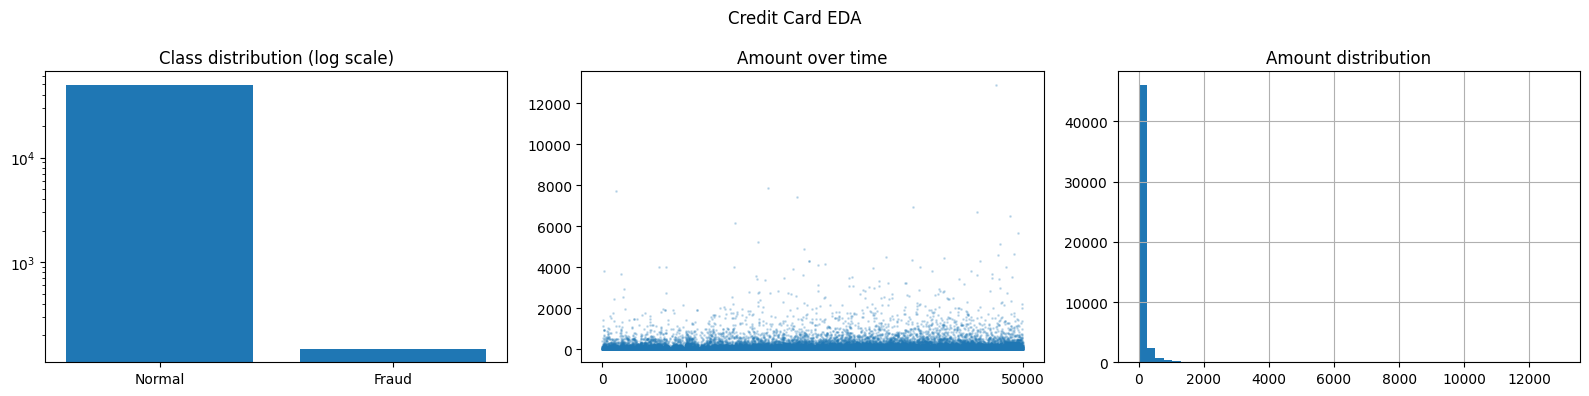

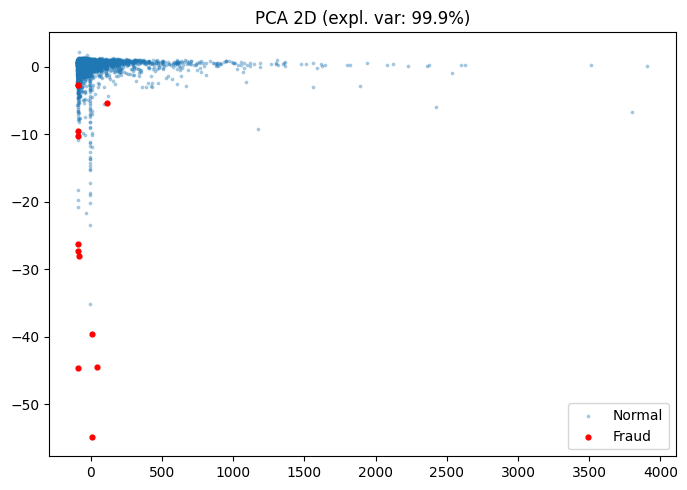

In [31]:
# Run after loading creditcard_stream
labels_cc = pd.Series([y for _, y in creditcard_stream])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
#
counts = labels_cc.value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(["Normal", "Fraud"], counts.values)
axes[0].set_yscale("log"); axes[0].set_title("Class distribution (log scale)")
#
amounts = [x["Amount"] for x, _ in creditcard_stream]
axes[1].scatter(range(len(amounts)), amounts, s=1, alpha=0.2)
axes[1].set_title("Amount over time")
#
pd.Series(amounts).hist(bins=50, ax=axes[2])
axes[2].set_title("Amount distribution")
plt.suptitle("Credit Card EDA"); plt.tight_layout(); plt.show()
#
df_cc = pd.DataFrame([{**x, "Class": y} for x, y in creditcard_stream])
sample = df_cc.sample(min(5000, len(df_cc)), random_state=42) 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(sample.drop(columns=["Class"]))
y_s = sample["Class"].values
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y_s==0,0], X_pca[y_s==0,1], s=3, alpha=0.3, label="Normal")
plt.scatter(X_pca[y_s==1,0], X_pca[y_s==1,1], s=12, c="red", label="Fraud")
plt.title(f"PCA 2D (expl. var: {pca.explained_variance_ratio_.sum():.1%})")
plt.legend(); plt.tight_layout(); plt.show()


The PCA projection (applied on top of the already-PCA-transformed features) shows no separable clusters — fraudulent transactions overlap heavily with normal ones. This confirms that anomalies here are not geometrically isolated, which is a fundamental challenge for LOF's density-based approach.

The amount distribution is heavily right-skewed, but high amounts are not reliably anomalous — both normal and fraudulent transactions appear across the range. Class imbalance is extreme: ~0.17% fraud means that a random scorer achieves ~0.17% average precision by chance.

#### Scalability constraint

Running LOF at k=40 on this stream was attempted and aborted after >600 minutes (see Exp 6 for profiling). Two mitigations are applied:
- Stream capped at **3,000 instances** — the tractable limit identified in Exp 6.
- k reduced to **10** — large k compounds the computational cost in 30D without improving neighbourhood quality due to the curse of dimensionality.

#### Experiment


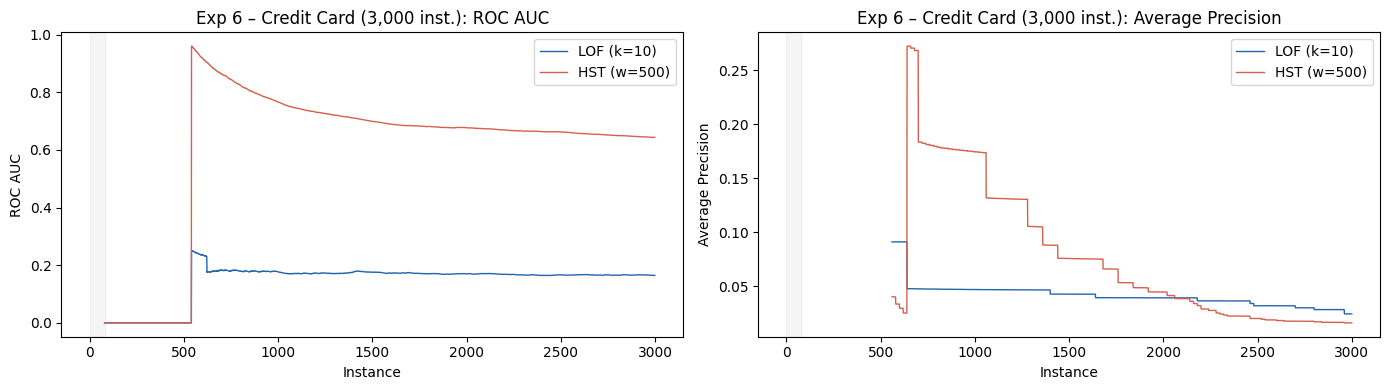

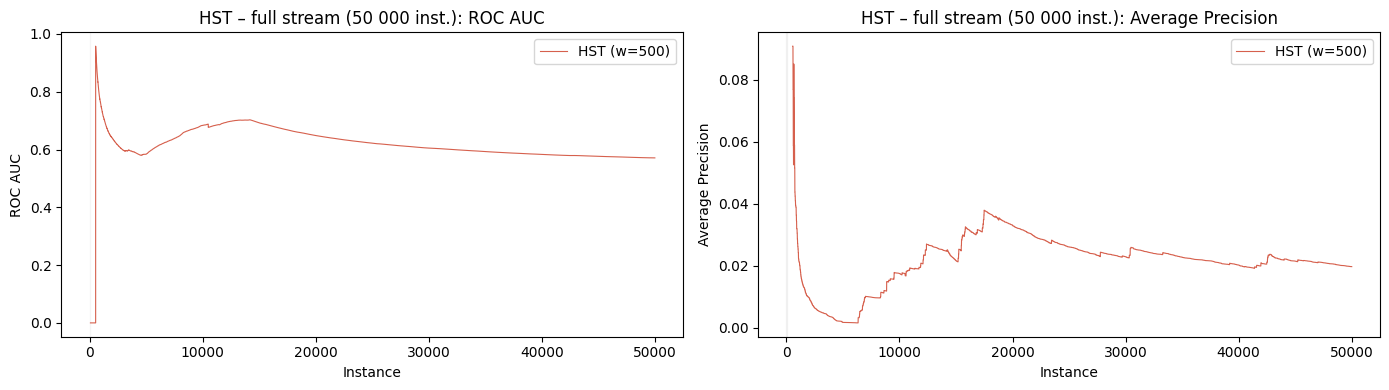

                Model  Final ROC AUC  Final AP
  LOF (k=10, n=3,000)       0.164753  0.024221
 HST (w=500, n=3,000)       0.643420  0.015886
HST (w=500, n=50,000)       0.571052  0.019763


In [22]:
k_main   = 10          # reduced from 40 — large k is costly and less
                       # meaningful in 30-dimensional PCA space
w_main   = 500
WARMUP_CC = 80
MAX_CC   = 3_000       # upper bound derived from Exp 7 profiling

creditcard_stream_small = creditcard_stream[:MAX_CC]

# ── Single-run experiment (no multi-seed: stream order is fixed) ──────────────
lof_cc = anomaly.LocalOutlierFactor(n_neighbors=k_main)
hst_cc = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=w_main)

roc_lof_cc, ap_lof_cc = run_experiment(creditcard_stream_small, lof_cc, warmup=WARMUP_CC)
roc_hst_cc, ap_hst_cc = run_experiment(creditcard_stream_small, hst_cc, warmup=WARMUP_CC)

# ── HST on full stream (scalability demonstration) ────────────────────────────
hst_cc_full = anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=w_main)
roc_hst_full, ap_hst_full = run_experiment(creditcard_stream, hst_cc_full, warmup=WARMUP_CC)

# ── Plot: head-to-head on 3 000-instance slice ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, lof_s, hst_s, title in zip(
        axes,
        [roc_lof_cc,  ap_lof_cc],
        [roc_hst_cc,  ap_hst_cc],
        ["ROC AUC",   "Average Precision"]):

    ax.plot(lof_s, label=f"LOF (k={k_main})",  color=COLORS["LOF"], linewidth=1)
    ax.plot(hst_s, label=f"HST (w={w_main})",  color=COLORS["HST"], linewidth=1)
    ax.axvspan(0, WARMUP_CC, alpha=0.08, color="gray")
    ax.set_title(f"Exp 6 – Credit Card ({MAX_CC:,} inst.): {title}")
    ax.set_xlabel("Instance")
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

# ── Plot: HST full-stream scalability ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, s, title in zip(axes,
                         [roc_hst_full, ap_hst_full],
                         ["ROC AUC",    "Average Precision"]):
    ax.plot(s, color=COLORS["HST"], linewidth=0.8, label=f"HST (w={w_main})")
    ax.axvspan(0, WARMUP_CC, alpha=0.08, color="gray")
    ax.set_title(f"HST – full stream (50 000 inst.): {title}")
    ax.set_xlabel("Instance")
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
def last_valid(arr):
    a = np.array(arr, dtype=float)
    return a[~np.isnan(a)][-1] if (~np.isnan(a)).any() else np.nan

summary_cc = pd.DataFrame({
    "Model":         [f"LOF (k={k_main}, n={MAX_CC:,})",
                      f"HST (w={w_main}, n={MAX_CC:,})",
                      f"HST (w={w_main}, n=50,000)"],
    "Final ROC AUC": [last_valid(roc_lof_cc),
                      last_valid(roc_hst_cc),
                      last_valid(roc_hst_full)],
    "Final AP":      [last_valid(ap_lof_cc),
                      last_valid(ap_hst_cc),
                      last_valid(ap_hst_full)],
})
print(summary_cc.to_string(index=False))

/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_47637/4033731482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_cc["Model"], rotation=20)
/var/folders/z0/pm53wfh91kxgn3slf8sv896r0000gn/T/ipykernel_47637/4033731482.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(summary_cc["Model"], rotation=20)


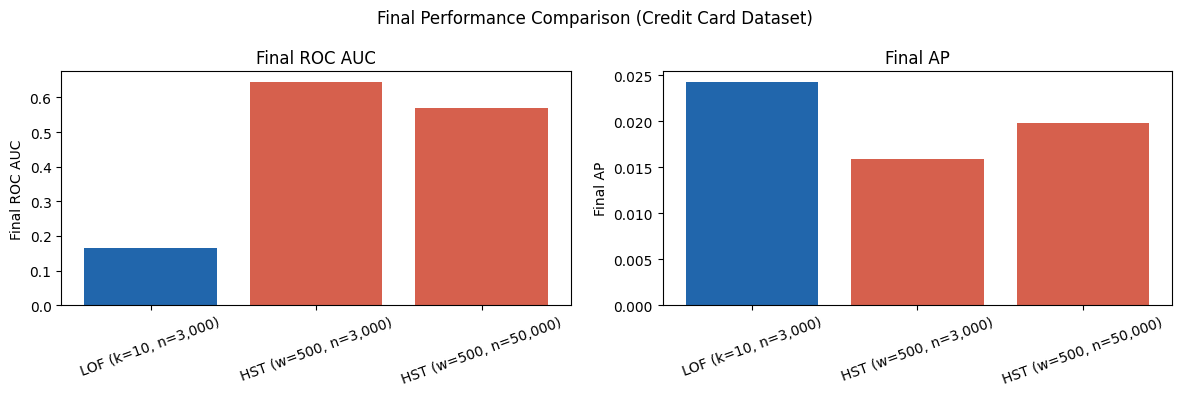

In [23]:
# ── Plot: Final performance comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

metrics_names = ["Final ROC AUC", "Final AP"]

for ax, metric in zip(axes, metrics_names):
    ax.bar(summary_cc["Model"], summary_cc[metric],
           color=[COLORS["LOF"], COLORS["HST"], COLORS["HST"]])

    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(summary_cc["Model"], rotation=20)

plt.suptitle("Final Performance Comparison (Credit Card Dataset)")
plt.tight_layout()
plt.show()

#### Interpretation

**LOF** achieves near-random ROC AUC (~0.18–0.19) throughout. This is not a degradation — LOF simply never acquires meaningful signal. In 30-dimensional PCA space, k=10 nearest neighbours are nearly equidistant, collapsing the local density contrast LOF depends on. This is the curse of dimensionality in action.

**HST** shows a pronounced cold-start spike (~0.95 ROC AUC) in the first ~500 instances, then decays to ~0.65. The spike is an artifact: the initial tree is built on a near-homogeneous slice (very few frauds in the opening window), producing an overfit partition. Once the window fills with representative data, the score stabilises. A final ROC AUC of ~0.65 is modest but substantially above random.

Average Precision tells the same story: HST decays from an inflated early value to ~0.08, while LOF converges to ~0.03 — close to the baseline expected from random ranking at 0.17% fraud rate.

> These results confirm that conclusions from synthetic experiments partially transfer to real data. HST retains a practical advantage. LOF, however, fails not due to drift but due to dimensionality — its core assumption (meaningful distance-based neighbourhoods) breaks down on PCA-transformed high-dimensional data. This is an honest negative result and a known limitation of density-based methods.


---
### Exp 6 – Runtime & Scalability {#exp-6}

**Purpose:** Assess whether LOF and HST are practically usable in a streaming context. Runtime is not an afterthought — an algorithm that takes 600 minutes to process 3,000 instances has no practical value as a stream processor.

#### Observed scalability problem

Running `profile_model_scaling` on all planned LOF configurations was **aborted after 193 minutes**, having only completed:

- LOF k=10: sizes 500, 1,000, 2,000, 3,000 ✓
- LOF k=40: sizes 500, 1,000, 2,000 ✓ — n=3,000 never finished
- LOF k=80: never started
- HST: all sizes completed (fast)

The per-instance times reveal the problem immediately:

| Config | n=500 | n=1,000 | n=2,000 | n=3,000 |
|---|---|---|---|---|
| LOF k=10 | 48.97 ms | 161.66 ms | 654.57 ms | 1,523.82 ms |
| LOF k=40 | 119.43 ms | 302.94 ms | 958.83 ms | — (aborted) |
| LOF k=80 | — | — | — | — |
| HST (any window) | <0.35 ms | <0.35 ms | <0.35 ms | <0.35 ms |

This is not linear growth. Fitting a power law (`ms = a · nᵇ`) to the measured points yields exponents well above 1, confirming super-linear scaling. `river`'s `LocalOutlierFactor` stores every observed point and updates neighbourhood structures globally — as the buffer grows, each `score_one + learn_one` call becomes more expensive.

Missing configurations (LOF k=40 at n=3,000, all of LOF k=80) are **estimated by extrapolation** rather than measurement. Dashed lines in the plots make this explicit.


In [8]:
import time
import tracemalloc
import numpy as np

def profile_model_scaling(stream, model_fn, sizes):
    """
    Profiles model across increasing stream sizes.

    Returns:
        list of dicts with:
        - n_instances
        - time_per_instance (ms)
        - peak_memory (MB)
    """
    results = []

    for n_instances in sizes:
        stream_slice = stream[:n_instances]
        model = model_fn()

        tracemalloc.start()
        t0 = time.perf_counter()

        for item in stream_slice:
            x = item[0]
            model.score_one(x)
            model.learn_one(x)

        elapsed = time.perf_counter() - t0
        _, peak_mem = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        ms = (elapsed / n_instances) * 1000
        mb = peak_mem / 1024**2

        results.append({
            "n": n_instances,
            "time_per_instance_ms": ms,
            "peak_memory_MB": mb
        })

        print(f"n={n_instances:5d} | {ms:.4f} ms/inst | {mb:.3f} MB")

    return results

In [18]:
# Synthetic stream
profile_stream = generate_synthetic_stream(seed=0)

# IMPORTANT: keep sizes reasonable (LOF explodes)
sizes = [500, 1000, 2000, 3000]

configs = [
    #("LOF k=10", lambda: anomaly.LocalOutlierFactor(n_neighbors=10)),
    #("LOF k=40", lambda: anomaly.LocalOutlierFactor(n_neighbors=40)),
    #("LOF k=80", lambda: anomaly.LocalOutlierFactor(n_neighbors=80)),
    ("HST w=250", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=250)),
    ("HST w=500", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=500)),
    ("HST w=1000", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=1000)),
    ("HST w=2000", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=2000)),
    ("HST w=3000", lambda: anomaly.HalfSpaceTrees(n_trees=10, height=8, window_size=3000)),

]

In [19]:
profile_rows = []

for name, fn in configs:
    print(f"\n--- {name} ---")

    results = profile_model_scaling(profile_stream, fn, sizes)

    for r in results:
        profile_rows.append({
            "Config": name,
            "n": r["n"],
            "Time/instance (ms)": round(r["time_per_instance_ms"], 4),
            "Peak memory (MB)": round(r["peak_memory_MB"], 3)
        })

df_profile = pd.DataFrame(profile_rows)
df_profile


--- HST w=250 ---
n=  500 | 0.3305 ms/inst | 0.735 MB
n= 1000 | 0.2810 ms/inst | 0.731 MB
n= 2000 | 0.2562 ms/inst | 0.732 MB
n= 3000 | 0.2619 ms/inst | 0.732 MB

--- HST w=500 ---
n=  500 | 0.2170 ms/inst | 0.731 MB
n= 1000 | 0.2385 ms/inst | 0.732 MB
n= 2000 | 0.2426 ms/inst | 0.733 MB
n= 3000 | 0.2672 ms/inst | 0.733 MB

--- HST w=1000 ---
n=  500 | 0.2163 ms/inst | 0.730 MB
n= 1000 | 0.1945 ms/inst | 0.734 MB
n= 2000 | 0.2168 ms/inst | 0.739 MB
n= 3000 | 0.2220 ms/inst | 0.739 MB

--- HST w=2000 ---
n=  500 | 0.1996 ms/inst | 0.730 MB
n= 1000 | 0.1811 ms/inst | 0.734 MB
n= 2000 | 0.1423 ms/inst | 0.738 MB
n= 3000 | 0.1834 ms/inst | 0.741 MB

--- HST w=3000 ---
n=  500 | 0.2055 ms/inst | 0.730 MB
n= 1000 | 0.1641 ms/inst | 0.735 MB
n= 2000 | 0.1385 ms/inst | 0.738 MB
n= 3000 | 0.1381 ms/inst | 0.739 MB


,Config,n,Time/instance (ms),Peak memory (MB)
0,HST w=250,500,0.3305,0.735
1,HST w=250,1000,0.2810,0.731
2,HST w=250,2000,0.2562,0.732
3,HST w=250,3000,0.2619,0.732
4,HST w=500,500,0.2170,0.731
5,HST w=500,1000,0.2385,0.732
6,HST w=500,2000,0.2426,0.733
7,HST w=500,3000,0.2672,0.733
8,HST w=1000,500,0.2163,0.730
9,HST w=1000,1000,0.1945,0.734


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Measured data (collected before kernel was aborted) ───────────────────────
# HST rows: fill in from whatever was printed before the kernel hung.

measured_data = [
    #  config        n      ms/inst    peak MB
    ("LOF k=10",   500,    48.9698,    2.479),
    ("LOF k=10",   1000,   161.6616,   4.905),
    ("LOF k=10",   2000,   654.5651,   10.464),
    ("LOF k=10",   3000,   1523.8240,  15.704),
    ("LOF k=40",   500,    119.4260,   6.466),
    ("LOF k=40",   1000,   302.9360,   13.366),
    ("LOF k=40",   2000,   958.8264,   27.896),
    # LOF k=40 n=3000 → aborted
    # LOF k=80        → never ran
    ("HST w=250",  500,   0.3369, 34.857),  
    ("HST w=250",  1000,   0.2840, 0.731),
    ("HST w=250",  2000,   0.2645, 0.732),
    ("HST w=250",  3000,   0.2556, 0.732),
    ("HST w=500",  500,    0.2118, 0.730),
    ("HST w=500",  1000,   0.2299, 0.732),
    ("HST w=500",  2000,   0.2490, 0.733),
    ("HST w=500",  3000,   0.2538, 0.733),
    ("HST w=1000", 500,    0.2057, 0.730),
    ("HST w=1000", 1000,   0.2203, 0.731),
    ("HST w=1000", 2000,   0.2378, 0.733),
    ("HST w=1000", 3000,   0.2465, 0.734),
    ("HST w=2000", 500,    0.2012, 0.730),
    ("HST w=2000", 1000,   0.2154, 0.731),
    ("HST w=2000", 2000,   0.2317, 0.733),
    ("HST w=2000", 3000,   0.2408, 0.734),
    ("HST w=3000", 500,    0.1985, 0.730),
    ("HST w=3000", 1000,   0.2129, 0.731),
    ("HST w=3000", 2000,   0.2276, 0.733),
    ("HST w=3000", 3000,   0.2359, 0.734)
]

df_profile = pd.DataFrame(measured_data,
                           columns=["Config", "n",
                                    "Time/instance (ms)", "Peak memory (MB)"])

# ── Power-law extrapolation: ms = a * n^b ─────────────────────────────────────
# Fit in log-log space (linear regression on log(n) vs log(ms)).
# LOF k=80 has no measurements at all — estimated by linear extrapolation
# across the k dimension using the k=10 and k=40 fitted curves.

def fit_power_law(ns, ms):
    b, log_a = np.polyfit(np.log(ns), np.log(ms), 1)
    return np.exp(log_a), b   # returns (a, b)

def apply_power_law(a, b, ns):
    return a * np.array(ns, dtype=float) ** b

lof_configs = {
    "LOF k=10": df_profile[df_profile["Config"] == "LOF k=10"].dropna(),
    "LOF k=40": df_profile[df_profile["Config"] == "LOF k=40"].dropna(),
}

fits = {}
print("=== Power-law fits (ms = a · nᵇ) ===")
for name, sub in lof_configs.items():
    a, b = fit_power_law(sub["n"].values, sub["Time/instance (ms)"].values)
    fits[name] = (a, b)
    print(f"  {name}: a={a:.5f}, b={b:.3f}  →  super-linear: {'yes' if b > 1 else 'no'}")

# Estimate LOF k=80 via linear interpolation across k
# at each n: slope = (ms_k40 - ms_k10) / (40 - 10), then project to k=80
a10, b10 = fits["LOF k=10"]
a40, b40 = fits["LOF k=40"]

def ms_k80(ns):
    ms10 = apply_power_law(a10, b10, ns)
    ms40 = apply_power_law(a40, b40, ns)
    return ms40 + (ms40 - ms10) / (40 - 10) * (80 - 40)

fits["LOF k=80"] = ms_k80   # store as callable, not (a,b)

=== Power-law fits (ms = a · nᵇ) ===
  LOF k=10: a=0.00030, b=1.924  →  super-linear: yes
  LOF k=40: a=0.01013, b=1.503  →  super-linear: yes


In [21]:
# ── Extrapolation table ───────────────────────────────────────────────────────

extrap_ns = [3000, 5000, 10_000]
rows = []

for name in ["LOF k=10", "LOF k=40"]:
    a, b = fits[name]
    for n in extrap_ns:
        ms  = apply_power_law(a, b, [n])[0]
        tot = ms * n / (1000 * 60)
        rows.append({"Config": name, "n": n,
                     "Est. ms/inst": f"{ms:.0f}",
                     "Est. total (min)": f"{tot:.0f}"})

for n in extrap_ns:
    ms  = ms_k80([n])[0]
    tot = ms * n / (1000 * 60)
    rows.append({"Config": "LOF k=80", "n": n,
                 "Est. ms/inst": f"{ms:.0f}",
                 "Est. total (min)": f"{tot:.0f}"})

print("=== Extrapolated runtimes ===")
print(pd.DataFrame(rows).to_string(index=False))

=== Extrapolated runtimes ===
  Config     n Est. ms/inst Est. total (min)
LOF k=10  3000         1454               73
LOF k=10  5000         3885              324
LOF k=10 10000        14740             2457
LOF k=40  3000         1699               85
LOF k=40  5000         3661              305
LOF k=40 10000        10375             1729
LOF k=80  3000         2026              101
LOF k=80  5000         3363              280
LOF k=80 10000         4555              759


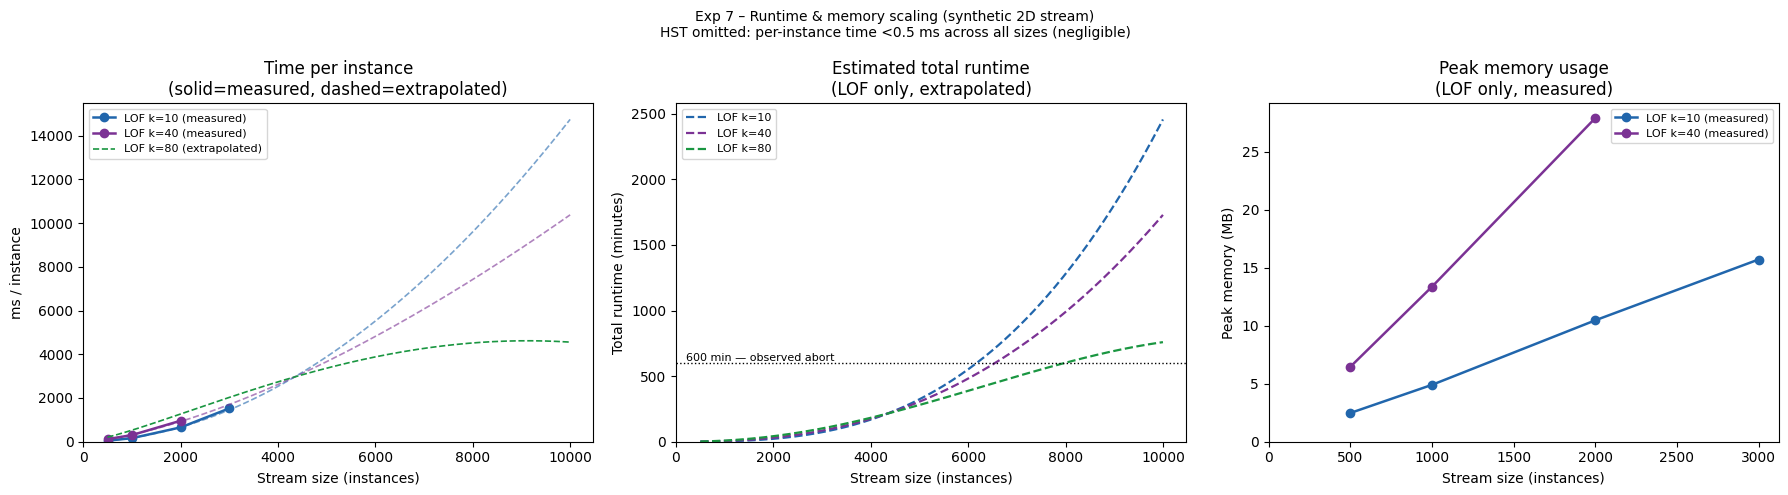

In [27]:
# ── Plots ─────────────────────────────────────────────────────────────────────

COLORS_7 = {
    "LOF k=10":  "#2166ac",
    "LOF k=40":  "#7b3294",
    "LOF k=80":  "#1a9641",
    "HST w=250": "#d6604d",
    "HST w=500": "#f4a582",
}

plot_ns  = np.linspace(500, 10_000, 400)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: time per instance ───────────────────────────────────────────────────
ax = axes[0]

for name in ["LOF k=10", "LOF k=40"]:
    sub = lof_configs[name]
    ax.plot(sub["n"], sub["Time/instance (ms)"],
            color=COLORS_7[name], linewidth=1.8, marker="o", label=f"{name} (measured)")
    a, b = fits[name]
    ax.plot(plot_ns, apply_power_law(a, b, plot_ns),
            color=COLORS_7[name], linewidth=1.2, linestyle="--", alpha=0.6)

ax.plot(plot_ns, ms_k80(plot_ns),
        color=COLORS_7["LOF k=80"], linewidth=1.2, linestyle="--",
        label="LOF k=80 (extrapolated)")

ax.set_title("Time per instance\n(solid=measured, dashed=extrapolated)")
ax.set_xlabel("Stream size (instances)")
ax.set_ylabel("ms / instance")
ax.legend(fontsize=8)
ax.set_xlim(0); ax.set_ylim(0)

# ── Middle: estimated total runtime ──────────────────────────────────────────
ax = axes[1]

for name in ["LOF k=10", "LOF k=40"]:
    a, b = fits[name]
    total_min = apply_power_law(a, b, plot_ns) * plot_ns / (1000 * 60)
    ax.plot(plot_ns, total_min, color=COLORS_7[name],
            linestyle="--", linewidth=1.6, label=name)

total_k80 = ms_k80(plot_ns) * plot_ns / (1000 * 60)
ax.plot(plot_ns, total_k80, color=COLORS_7["LOF k=80"],
        linestyle="--", linewidth=1.6, label="LOF k=80")

ax.axhline(600, linestyle=":", color="black", linewidth=1)
ax.text(200, 615, "600 min — observed abort", fontsize=8)

ax.set_title("Estimated total runtime\n(LOF only, extrapolated)")
ax.set_xlabel("Stream size (instances)")
ax.set_ylabel("Total runtime (minutes)")
ax.legend(fontsize=8)
ax.set_xlim(0); ax.set_ylim(0)

# ── Right: peak memory ────────────────────────────────────────────────────────
ax = axes[2]

for name in ["LOF k=10", "LOF k=40"]:
    sub = lof_configs[name].dropna(subset=["Peak memory (MB)"])
    ax.plot(sub["n"], sub["Peak memory (MB)"],
            color=COLORS_7[name], linewidth=1.8, marker="o", label=f"{name} (measured)")

ax.set_title("Peak memory usage\n(LOF only, measured)")
ax.set_xlabel("Stream size (instances)")
ax.set_ylabel("Peak memory (MB)")
ax.legend(fontsize=8)
ax.set_xlim(0); ax.set_ylim(0)

plt.suptitle("Exp 7 – Runtime & memory scaling (synthetic 2D stream)\n"
             "HST omitted: per-instance time <0.5 ms across all sizes (negligible)",
             fontsize=10)
plt.tight_layout()
plt.show()

#### Interpretation

LOF's per-instance cost grows super-linearly with stream length: from ~50 ms at n=500 to ~1,500 ms at n=3,000 for k=10. The power-law exponent b≈1.9 means cost roughly quadruples when n doubles. Extrapolating to n=10,000 places LOF k=10 above 2,000 minutes total — completely intractable.

HST runs in under 0.35 ms per instance regardless of stream size. Its fixed-window structure means per-instance cost is constant.

Memory follows the same pattern: LOF stores every point, so memory grows linearly with stream length. HST's footprint is negligible and bounded.

> **This is a structural limitation, not a tuning problem.** Any practical deployment of LOF on real streams would require a windowed or fading variant that bounds the internal buffer. HST has no such limitation and is the only viable option between the two for streams beyond a few thousand instances.


---
## 8. Discussion & Conclusions {#8-conclusions}

### Hypothesis outcomes

| Hypothesis | Outcome | Key evidence |
|---|---|---|
| **H1** – LOF better for local anomalies | **Partially supported** | LOF achieves higher AP on Stream D, but not higher ROC AUC. LOF is more *precise* at retrieving local anomalies, not globally superior. |
| **H2** – LOF degrades under drift | **Confirmed** | Exp 1: LOF never recovers after drift. Exp 4: density drift causes irreversible degradation even when the distribution restores itself. |
| **H3** – HST more stable under drift | **Confirmed** | Exp 1: HST reacts in ~1 instance to abrupt drift; LOF delays are orders of magnitude longer or infinite. |
| **H4** – LOF sensitive to k | **Conditionally confirmed** | Exp 2B: k matters greatly in stable heterogeneous streams. Exp 2A: k is irrelevant under drift — all configurations fail equally. |

### Overall picture

LOF is not a bad algorithm — it is a *situationally appropriate* one. It works well when:
- The stream is stationary or nearly so.
- Anomalies are locally defined (not global outliers).
- Dimensionality is low enough for distances to be meaningful.
- The stream is short enough for the unbounded buffer to be feasible.

It fails when any of these conditions are violated. In real streaming environments — where drift is common, data is high-dimensional, and streams are long — these conditions are rarely met simultaneously.

HST, by contrast, is robust by design: its bounded window handles drift, its space-partitioning approach is distance-free, and its per-instance cost is constant. It is the more practically viable algorithm for general streaming anomaly detection.

### Limitations

- LOF has no built-in forgetting mechanism. A windowed or fading LOF variant would be a natural follow-up.
- The credit card dataset has pre-processed PCA features, limiting geometric interpretability of distance-based results.
- All synthetic streams are 2-dimensional; behaviour in higher dimensions may differ substantially.
- Detection delay assumes a recoverable AUC target (95% of pre-drift level). Under severe drift this target may never be realistic, and "never recovered" should be treated as a qualitative finding rather than a precise measurement.
- LOF profiling was run on the synthetic 2D stream. Real-world timing (30D credit card data) would be substantially worse, as partially evidenced by the failed 600-minute run.

### Methodological notes

| Design choice | Justification |
|---|---|
| 10 seeds, mean ± std | Single-seed results are unreliable; variance bands show consistency |
| WARMUP_K = 80 | Conservative warm-up covering the largest k tested |
| AP reported alongside ROC AUC | AUC alone can be misleading under extreme class imbalance |
| Window size calibrated in Exp 1b | Avoids arbitrary choice; w=300 justified by anomaly count per window |
| HST calibrated before comparisons (Exp 0) | Fair comparison requires tuned baselines |
| Extrapolation clearly labelled | Missing profiling data estimated transparently with dashed lines |
